# Préparation des données et Entrainement du modèle

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn import svm
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB
from sklearn.utils import shuffle

Le dataset d'entrainement ne contient que des images de la meme main, centrée au milieu de l'image. Celui de test fait varier la position et contient les deux mains.

In [2]:
df = pd.read_csv("../data/asl_two_hands.csv")
X = df.drop(["label"], axis=1).to_numpy(dtype=np.float32)
y = df["label"].to_numpy(dtype=int)

In [3]:
#df = pd.read_csv("../data/asl_one_hand.csv")
#X = df.drop(["label"], axis=1).to_numpy(dtype=np.float32)
#y = df["label"].to_numpy(dtype=int)

In [4]:
df.describe()

,p0,p1,p2,p3,p4,p5,p6,p7,p8,p9,...,p54,p55,p56,p57,p58,p59,p60,p61,p62,label
count,2196.000000,2196.000000,2.196000e+03,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,...,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000
mean,0.499520,0.785614,7.162592e-08,0.501319,0.731506,-0.029305,0.502206,0.649421,-0.043127,0.505186,...,0.502500,0.581156,-0.077361,0.503860,0.605841,-0.076463,0.504939,0.618100,-0.067921,12.381148
std,0.062091,0.090590,7.231586e-07,0.084417,0.095146,0.056153,0.109546,0.090300,0.075733,0.114926,...,0.091566,0.114291,0.069462,0.087335,0.131806,0.065864,0.087688,0.147414,0.066519,7.418255
min,0.285463,0.539796,-1.911988e-06,0.261395,0.457896,-0.200527,0.208604,0.425734,-0.308229,0.185937,...,0.277740,0.302978,-0.369514,0.257675,0.259695,-0.348201,0.262276,0.222274,-0.331042,0.000000
25%,0.470655,0.712795,-5.343814e-07,0.426242,0.656464,-0.059958,0.403086,0.575007,-0.082079,0.410010,...,0.435048,0.527894,-0.112606,0.446592,0.526128,-0.111050,0.450378,0.533902,-0.104752,6.000000
50%,0.499186,0.787726,2.894353e-08,0.501959,0.738758,-0.033789,0.508274,0.644761,-0.046537,0.507912,...,0.503406,0.569524,-0.069402,0.503902,0.611000,-0.069713,0.504033,0.643543,-0.061121,12.000000
75%,0.528944,0.855434,6.582735e-07,0.577699,0.807613,-0.009337,0.601727,0.726388,-0.016290,0.603221,...,0.571985,0.646454,-0.036425,0.563788,0.692380,-0.037712,0.560509,0.711838,-0.026666,19.000000
max,0.703762,1.026936,2.104025e-06,0.734820,0.959368,0.163881,0.784909,0.881350,0.220599,0.792322,...,0.718144,0.874966,0.172787,0.728984,0.914789,0.191089,0.748989,0.960058,0.193204,25.000000


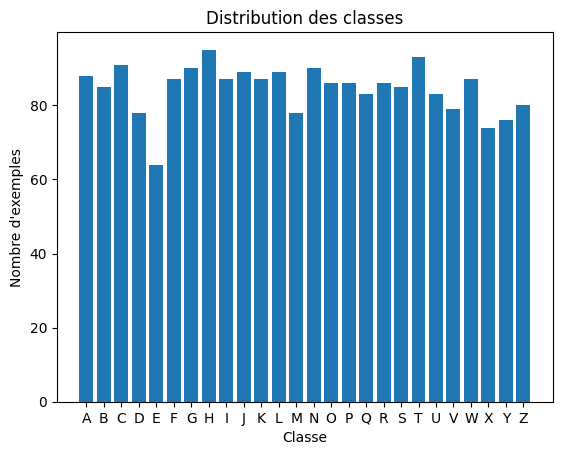

In [5]:
labels, counts = np.unique(y,return_counts=True)
plt.bar(labels,counts)
plt.xticks(labels, [chr(65+i) for i in labels])
plt.xlabel("Classe")
plt.ylabel("Nombre d'exemples")
plt.title("Distribution des classes")
plt.show()

## Pré-traitement
Ici les 63 features correspondent a la position (x,y,z) de chacun des 21 points pris sur la main.
Les valeurs correspondent à la position dite 'absolue' des points sur l'image, or nous ne souhaitons pas determiner le signe à partir de la position de la main sur l'ecran mais plutot à partir de la position dite 'relative' de chaque point par rapport au centre de gravité de la main.
Dans la suite on considerera que le centre de gravité correspond à au point moyen de la main.
Pour avoir ces coordonnées relatives on soustrait le centre de gravité de la main à chacun de ses points. 

Nous allons tester les performances d'un modele sur les données brutes avec les positions absolue des points, puis avec les position relative au centre de gravité.

In [6]:
# Coordonnées Absolues
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = svm.SVC()
clf.fit(X_train, y_train)

print(f"Performance sur l'ensemble d'entrainement : {clf.score(X_train, y_train)}")
print(f"Performance sur l'ensemble de test : {clf.score(X_test, y_test)}")

Performance sur l'ensemble d'entrainement : 0.8929384965831435
Performance sur l'ensemble de test : 0.9113636363636364


In [7]:
def distance(X1, X2):
    return np.linalg.norm(X1-X2)

In [8]:
X_inter = X.reshape(X.shape[0],21,3)
X_processed = np.zeros((X.shape[0],63))
cnt = 0
for i in range(X_inter.shape[0]):

    dist_norm = distance(X_inter[i,0],X_inter[i,9])
    mean = X_inter[i].mean(axis=0)
    X_i = (X_inter[i] - mean)/dist_norm
    X_processed[cnt] = X_i.reshape(63) 
    cnt+=1

X = X_processed

In [10]:
# Coordonnées Relative
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = svm.SVC()
clf.fit(X_train, y_train)

print(f"Performance sur l'ensemble d'entrainement : {clf.score(X_train, y_train)}")
print(f"Performance sur l'ensemble de test : {clf.score(X_test, y_test)}")

Performance sur l'ensemble d'entrainement : 0.989749430523918
Performance sur l'ensemble de test : 0.9818181818181818


Il y a une legere amelioration sur les coordonnées relatives, les resultats du premier modèle avec coordonées absolues ne sont pas très representatifs car la main se trouve presque à la même position dans chacune des images du dataset. 

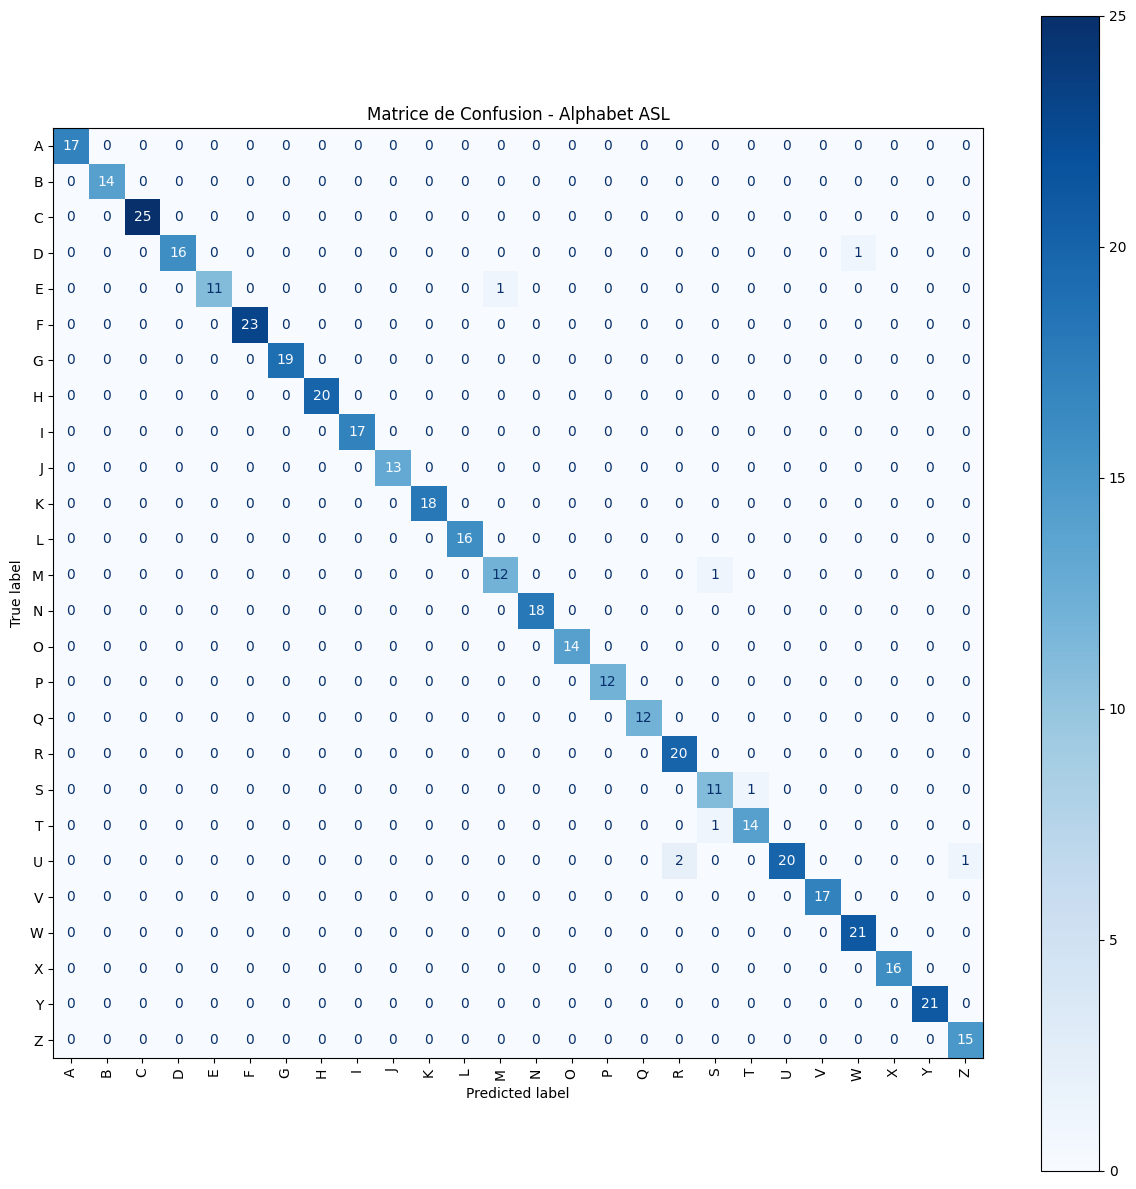

In [12]:
labels = [chr(65+i) for i in range(26)]
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(15, 15))

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

cm_display.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')

plt.title("Matrice de Confusion - Alphabet ASL")
plt.show()

## Entrainement des modèles

### SVC
On veut pouvoir predire le signe, et données la probabilité associé

In [22]:
clf = svm.SVC(probability = True)
clf.fit(X_train, y_train)

print(f"Performance sur l'ensemble d'entrainement : {clf.score(X_train, y_train)}")
print(f"Performance sur l'ensemble de test : {clf.score(X_test, y_test)}")

Performance sur l'ensemble d'entrainement : 0.989749430523918
Performance sur l'ensemble de test : 0.9818181818181818


In [23]:
joblib.dump(clf, "../models/svc.pkl")

['../models/svc.pkl']

### Modèle Bayesien
On veut pouvoir entrainer un modèle probabiliste bayesien. Pour ce faire, il faut d'abord observer la distribution des données pour choisir une loi.
Prenons les extremités du pouce et de l'auriculaire.

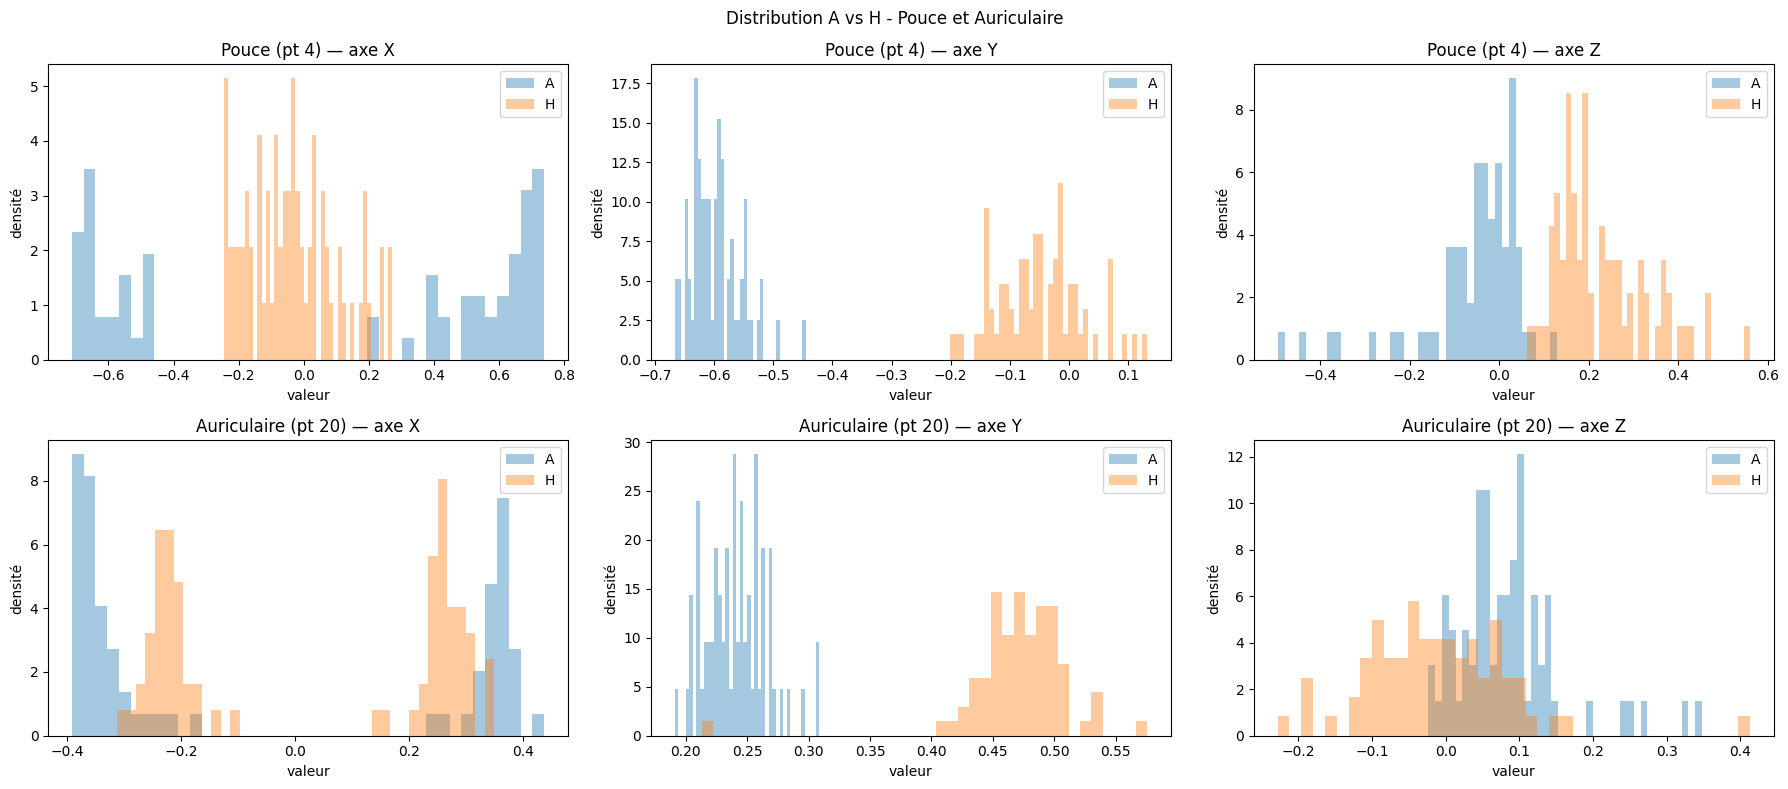

In [27]:
label_map = {chr(65+i): i for i in range(26)}
cmap = plt.get_cmap("tab10")
lettres = ['A', 'H']

mask_label = [(y_train == label_map[l], l, cmap(i)) for i, l in enumerate(lettres)]

points = {
    "Pouce (pt 4)":        (12, 13, 14),
    "Auriculaire (pt 20)": (60, 61, 62),
}
axes_names = ['X', 'Y', 'Z']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for row, (nom, (xi, yi, zi)) in enumerate(points.items()):
    for col, (feat_idx, axe) in enumerate(zip([xi, yi, zi], axes_names)):
        ax = axes[row][col]
        for mask, lettre, color in mask_label:
            data = X_train[mask, feat_idx]
            ax.hist(data, bins=40, density=True, alpha=0.4, color=color, label=lettre)
        ax.set_title(f"{nom} — axe {axe}")
        ax.set_xlabel("valeur")
        ax.set_ylabel("densité")
        ax.legend()

plt.suptitle("Distribution A vs H - Pouce et Auriculaire")
plt.tight_layout()
plt.show()

On remarque deux choses :

La premiere, c'est que les données semblent dans l'ensemble suivre une loi normale.

La seconde, c'est que sur l'axe X, la distribution est symetrique par rapport, c'est car dans le dataset, il y a des images des deux mains, dont la direction est inversé. Cela signifie que les deux courbes en cloches, correspondent aux distributions de la main gauche, ainsi que de la main droite. 
Cela ouvre la porte à non seulement la prédiction du signe, mais aussi à la prédiction de la direction (gauche/droite) de la main. Pour ce faire, il faudrait donc passer de 26 à 52 classes.

On n'ira pas plus loin avec ce modèle bien que ce soit une piste interessante, il ne faudra cependant pas utiliser une approche Naïve car nos données ne sont pas independantes, toutes les articulations d'un meme doigt sont correllées. On pourrait même exploré une variante où l'on calcule l'angle de rotation de la main sur les axes x, y et z.